In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/PINN', exist_ok=True)

In [ ]:
"""
PINN Elastodynamics — Step 1: Domain & Point Generation

Setup: Quarter plate (0 to 0.5 m in x and y) with a circular hole
         of radius 0.1 m centred at the origin, loaded dynamically
         over T=10 seconds.

  - XYT_c   : collocation points for PDE residuals  (N_c  × 3)
  - HOLE     : points on the hole surface            (N_h  × 3)
  - IC       : initial condition points  t=0         (N_ic × 3)
  - LF       : left symmetry edge   x=0              (N_lf × 3)
  - RT       : right loaded edge    x=0.5            (N_rt × 4)  [x,y,t,s11]
  - UP       : top free edge        y=0.5            (N_up × 3)
  - LW       : bottom symmetry edge y=0              (N_lw × 3)
  - DIST     : distance-function training data       (N_d  × 8)  [x,y,t,Du,Dv,Ds11,Ds22,Ds12]

"""

import math
import numpy as np
from scipy.stats.qmc import LatinHypercube
import matplotlib.pyplot as plt

#  reproducibility
np.random.seed(1111)

def lhs(d, n):

    seed = np.random.randint(0, 2**31)
    sampler = LatinHypercube(d=d, seed=seed)
    return sampler.random(n=n)

# global problem parameters
PI      = math.pi
MAX_T   = 10.0          # simulation duration  (s)
HOLE_R  = 0.1           # hole radius          (m)
HOLE_XC = 0.0           # hole centre x
HOLE_YC = 0.0           # hole centre y
PERIOD  = 5.0           # load period          (s)  → two cycles in 10 s


# lb = lower bound, ub = upper bound.
lb = np.array([0.0, 0.0, 0.0])
ub = np.array([0.5, 0.5, MAX_T])


def delete_hole_points(XYT, xc=HOLE_XC, yc=HOLE_YC, r=HOLE_R):

    dist = np.sqrt((XYT[:, 0] - xc)**2 + (XYT[:, 1] - yc)**2)
    return XYT[dist > r]


def gen_hole_surface_points(xc, yc, r, n_theta):

    theta = np.linspace(0.0, PI / 2.0, n_theta)
    xx = r * np.cos(theta) + xc
    yy = r * np.sin(theta) + yc
    return xx[:, None], yy[:, None]   # column vectors



# SECTION 1 — Collocation points  (XYT_c)


N_collo_global = 35_000
N_collo_refine = 20_000

# Global batch: lb + (ub-lb)*LHS maps [0,1]³ → [lb, ub]
XYT_c = lb + (ub - lb) * lhs(3, N_collo_global)

# Refinement batch: confined to x,y ∈ [0, 0.15], t ∈ [0, 10]
refine_ub = np.array([0.15, 0.15, MAX_T])
XYT_c_ref = lb + refine_ub * lhs(3, N_collo_refine)

XYT_c = np.concatenate([XYT_c, XYT_c_ref], axis=0)
XYT_c = delete_hole_points(XYT_c)   # remove points inside the void

print(f"Collocation points : {XYT_c.shape[0]:>7,}")



# SECTION 2 — Hole surface points  (HOLE)

#
# The circular hole surface is a Neumann boundary with zero traction:
#   σ · n = 0   (stress-free hole)


N_theta_hole = 83
N_t_hole     = 121        # includes t=0, which we then drop

xx_h, yy_h = gen_hole_surface_points(HOLE_XC, HOLE_YC, HOLE_R, N_theta_hole)
tt_h = np.linspace(0, MAX_T, N_t_hole)[1:]   # drop t=0  → 120 instants

# Cartesian product: every spatial point × every time instant
x_ho, t_ho = np.meshgrid(xx_h.ravel(), tt_h)
y_ho, _    = np.meshgrid(yy_h.ravel(), tt_h)

HOLE = np.stack([x_ho.ravel(), y_ho.ravel(), t_ho.ravel()], axis=1)
print(f"Hole surface points: {HOLE.shape[0]:>7,}")



# SECTION 3 — Initial condition points  (IC)


N_ic = 5_000

# lhs(3, N_ic) gives points in [0,1]³; we only use the x,y columns
# and fix t=0 by multiplying the t column by 0.
IC = lb + np.array([0.5, 0.5, 0.0]) * lhs(3, N_ic)
IC = delete_hole_points(IC)

print(f"IC points          : {IC.shape[0]:>7,}")



# SECTION 4 — Boundary points


N_lf = 8_000
N_lw = 8_000
N_up = 8_000
N_rt = 13_000

# Left symmetry
LF = np.array([0.0, 0.1, 0.0]) + np.array([0.0, 0.4, MAX_T]) * lhs(3, N_lf)

# Bottom symmetry
LW = np.array([0.1, 0.0, 0.0]) + np.array([0.4, 0.0, MAX_T]) * lhs(3, N_lw)

# Top free surface
UP = np.array([0.0, 0.5, 0.0]) + np.array([0.5, 0.0, MAX_T]) * lhs(3, N_up)

# Right loaded edge
RT = np.array([0.5, 0.0, 0.0]) + np.array([0.0, 0.5, MAX_T]) * lhs(3, N_rt)

# ── Applied traction on RT ────────────────────────────────────────────────────
# Tn(t) = 0.5·sin(2π/T₀·t + 3π/2) + 0.5
#

t_RT   = RT[:, 2:3]
s11_RT = 0.5 * np.sin((2 * PI / PERIOD) * t_RT + 1.5 * PI) + 0.5

# Append the load value as a 4th column: [x, y, t, σ₁₁]
RT = np.concatenate([RT, s11_RT], axis=1)

print(f"LF (left symm.)    : {LF.shape[0]:>7,}")
print(f"LW (bottom symm.)  : {LW.shape[0]:>7,}")
print(f"UP (top free)      : {UP.shape[0]:>7,}")
print(f"RT (right load)    : {RT.shape[0]:>7,}  [x,y,t,σ₁₁]")



# SECTION 5 — Distance function training data  (DIST)


# The distance network D(x,y,t) is pre-trained to approximate analytical
# functions that encode WHERE each field variable must vanish.



def gen_dist_points(xmin, xmax, ymin, ymax, tmin, tmax,
                    xc, yc, r, n_surf, n_xy, n_t):

    # Cartesian spatial grid
    x1d = np.linspace(xmin, xmax, n_xy)
    y1d = np.linspace(ymin, ymax, n_xy)
    xx, yy = np.meshgrid(x1d, y1d)

    # Delete points inside hole (purely spatial check)
    dist_grid = np.sqrt((xx - xc)**2 + (yy - yc)**2)
    mask = dist_grid >= r
    x_grid = xx[mask].ravel()[:, None]
    y_grid = yy[mask].ravel()[:, None]

    # Add refinement points ON the hole surface
    x_surf, y_surf = gen_hole_surface_points(xc, yc, r, n_surf)

    x_all = np.concatenate([x_grid, x_surf], axis=0)
    y_all = np.concatenate([y_grid, y_surf], axis=0)

    # Cartesian product with time axis
    t1d = np.linspace(tmin, tmax, n_t)
    xxx, ttt = np.meshgrid(x_all.ravel(), t1d)
    yyy, _   = np.meshgrid(y_all.ravel(), t1d)

    return (xxx.ravel()[:, None],
            yyy.ravel()[:, None],
            ttt.ravel()[:, None])


def compute_dist_values(XYT):

    x = XYT[:, 0]
    y = XYT[:, 1]
    t = XYT[:, 2]

    # Each distance is the minimum of the distances to its relevant
    # spatiotemporal boundaries.  np.minimum is the element-wise min.

    D_u   = np.minimum(t, x)                              # IC or left edge
    D_v   = np.minimum(t, y)                              # IC or bottom edge
    D_s11 = np.minimum(t, 0.5 - x)                        # IC or right edge
    D_s22 = np.minimum(t, 0.5 - y)                        # IC or top edge
    D_s12 = np.minimum(t,
            np.minimum(y,
            np.minimum(0.5 - y,
            np.minimum(x, 0.5 - x))))

    DIST = np.stack([x, y, t,
                     D_u, D_v, D_s11, D_s22, D_s12], axis=1)
    return DIST.astype(np.float64)


x_d, y_d, t_d = gen_dist_points(
    xmin=0, xmax=0.5, ymin=0, ymax=0.5,
    tmin=0, tmax=MAX_T,
    xc=HOLE_XC, yc=HOLE_YC, r=HOLE_R,
    n_surf=40, n_xy=21, n_t=21
)
XYT_dist = np.concatenate([x_d, y_d, t_d], axis=1)
DIST = compute_dist_values(XYT_dist)

print(f"DIST training pts  : {DIST.shape[0]:>7,}  [x,y,t,Du,Dv,Ds11,Ds22,Ds12]")



# SECTION 6 — Augment collocation set with boundary points




XYT_c = np.concatenate([
    XYT_c,
    HOLE[::4, :],          # every 4th hole point  (x,y,t only)
    LF[::5, :],            # every 5th LF point
    RT[::5, :3],           # every 5th RT point — drop the σ₁₁ column
    UP[::5, :],
    LW[::5, :],
], axis=0)

print(f"Collocation (final): {XYT_c.shape[0]:>7,}  (after boundary augmentation)")


# SECTION 7 — Cast everything to float64 and summarise


XYT_c = XYT_c.astype(np.float64)
HOLE  = HOLE.astype(np.float64)
IC    = IC.astype(np.float64)
LF    = LF.astype(np.float64)
LW    = LW.astype(np.float64)
UP    = UP.astype(np.float64)
RT    = RT.astype(np.float64)
DIST  = DIST.astype(np.float64)

print("\n── Summary of all point sets ───────────────────────────────────────")
print(f"  XYT_c  : {XYT_c.shape}   collocation (PDE residual)")
print(f"  HOLE   : {HOLE.shape}   hole surface (traction BC)")
print(f"  IC     : {IC.shape}   initial condition (t=0)")
print(f"  LF     : {LF.shape}   left symmetry (u=0, σ₁₂=0)")
print(f"  LW     : {LW.shape}   bottom symmetry (v=0, σ₁₂=0)")
print(f"  UP     : {UP.shape}   top free surface (σ₂₂=0, σ₁₂=0)")
print(f"  RT     : {RT.shape}   right load (σ₁₂=0, σ₁₁=Tn(t))")
print(f"  DIST   : {DIST.shape}   distance function targets")
print("─────────────────────────────────────────────────────────────────────")



# SECTION 8 — Visualisation


def plot_spatial_distribution():

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    fig.suptitle("Step 1 — Point sets (projected onto x-y plane)", fontsize=13)

    ax = axes[0]
    ax.set_title("All point sets (x-y projection)", fontsize=11)

    ax.scatter(XYT_c[:, 0], XYT_c[:, 1],
               s=0.3, alpha=0.15, color='steelblue', label='Collocation')
    ax.scatter(IC[:, 0],   IC[:, 1],
               s=1.0, alpha=0.4,  color='green',     label='IC (t=0)')
    ax.scatter(HOLE[:, 0], HOLE[:, 1],
               s=1.5, alpha=0.6,  color='red',       label='Hole surface')
    ax.scatter(LF[:, 0],   LF[:, 1],
               s=2.0, alpha=0.5,  color='orange',    label='LF (left sym.)')
    ax.scatter(LW[:, 0],   LW[:, 1],
               s=2.0, alpha=0.5,  color='purple',    label='LW (bot. sym.)')
    ax.scatter(UP[:, 0],   UP[:, 1],
               s=2.0, alpha=0.5,  color='brown',     label='UP (top free)')
    ax.scatter(RT[:, 0],   RT[:, 1],
               s=2.0, alpha=0.5,  color='magenta',   label='RT (right load)')

    # Draw hole boundary for reference
    theta_arc = np.linspace(0, PI/2, 200)
    ax.plot(HOLE_R * np.cos(theta_arc), HOLE_R * np.sin(theta_arc),
            'k-', linewidth=1.5, label='Hole arc')
    ax.set_xlim(-0.02, 0.55)
    ax.set_ylim(-0.02, 0.55)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=7, markerscale=3)

    # ── RIGHT: distance function at t=2.5 s 
    # Show D_u as a scatter plot to verify it's zero at x=0 and t=0.
    ax2 = axes[1]
    ax2.set_title("D̂_u(x, y, t=2.5 s) — distance function for u", fontsize=11)

    # Extract rows near t=2.5 from DIST
    t_target = 2.5
    mask_t = np.abs(DIST[:, 2] - t_target) < (MAX_T / (21 - 1)) * 0.6
    sub = DIST[mask_t]
    sc = ax2.scatter(sub[:, 0], sub[:, 1], c=sub[:, 3],
                     cmap='viridis', s=8, vmin=0)
    plt.colorbar(sc, ax=ax2, label='D̂_u value')
    ax2.set_xlabel("x [m]")
    ax2.set_ylabel("y [m]")
    ax2.set_aspect('equal')
    ax2.set_title("D̂_u(x,y,t≈2.5 s)\n"
                  "zero at x=0 (left sym.), nonzero inside", fontsize=10)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/PINN/step1_point_sets.png', dpi=150,
                bbox_inches='tight')
    plt.close()
    print("\nPlot saved → step1_point_sets.png")


def plot_load_history():

    t_plot = np.linspace(0, MAX_T, 500)
    Tn = 0.5 * np.sin((2 * PI / PERIOD) * t_plot + 1.5 * PI) + 0.5

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(t_plot, Tn, 'b-', linewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel("t [s]")
    ax.set_ylabel("σ₁₁ = Tn(t)  [kPa]")
    ax.set_title("Applied traction on right edge (RT)")
    ax.set_xlim(0, MAX_T)
    ax.set_ylim(-0.1, 1.15)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('step1_load_history.png', dpi=150,
                bbox_inches='tight')
    plt.close()
    print("Plot saved → step1_load_history.png")


def plot_dist_all_components():

    labels   = ['D̂_u', 'D̂_v', 'D̂_σ₁₁', 'D̂_σ₂₂', 'D̂_σ₁₂']
    col_idxs = [3, 4, 5, 6, 7]           # columns in DIST array
    zero_at  = ['x=0 or t=0', 'y=0 or t=0',
                 'x=0.5 or t=0', 'y=0.5 or t=0', 'all edges or t=0']

    t_target = 2.5
    tol = (MAX_T / (21 - 1)) * 0.6
    mask_t = np.abs(DIST[:, 2] - t_target) < tol
    sub = DIST[mask_t]

    fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))
    fig.suptitle(f"All distance function components at t ≈ {t_target} s",
                 fontsize=12)

    for ax, lbl, cidx, note in zip(axes, labels, col_idxs, zero_at):
        vals = sub[:, cidx]
        sc = ax.scatter(sub[:, 0], sub[:, 1], c=vals,
                        cmap='plasma', s=6, vmin=0, vmax=vals.max())
        plt.colorbar(sc, ax=ax, shrink=0.8)
        ax.set_title(f"{lbl}\n(zero at: {note})", fontsize=8)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_aspect('equal')

    plt.tight_layout()
    plt.savefig('step1_dist_components.png',
                dpi=150, bbox_inches='tight')
    plt.close()
    print("Plot saved → step1_dist_components.png")


plot_spatial_distribution()
plot_load_history()
plot_dist_all_components()

print("\nStep 1 complete.")
print("Next: Step 2 — build the base MLP class in PyTorch and verify")
print("      that torch.autograd.grad flows through it correctly.")

Collocation points :  46,980
Hole surface points:   9,960
IC points          :   4,869
LF (left symm.)    :   8,000
LW (bottom symm.)  :   8,000
UP (top free)      :   8,000
RT (right load)    :  13,000  [x,y,t,σ₁₁]
DIST training pts  :   9,786  [x,y,t,Du,Dv,Ds11,Ds22,Ds12]
Collocation (final):  56,870  (after boundary augmentation)

── Summary of all point sets ───────────────────────────────────────
  XYT_c  : (56870, 3)   collocation (PDE residual)
  HOLE   : (9960, 3)   hole surface (traction BC)
  IC     : (4869, 3)   initial condition (t=0)
  LF     : (8000, 3)   left symmetry (u=0, σ₁₂=0)
  LW     : (8000, 3)   bottom symmetry (v=0, σ₁₂=0)
  UP     : (8000, 3)   top free surface (σ₂₂=0, σ₁₂=0)
  RT     : (13000, 4)   right load (σ₁₂=0, σ₁₁=Tn(t))
  DIST   : (9786, 8)   distance function targets
─────────────────────────────────────────────────────────────────────

Plot saved → step1_point_sets.png
Plot saved → step1_load_history.png
Plot saved → step1_dist_components.png

Step 1

In [ ]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, layers):

        super().__init__()

        self.linears = nn.ModuleList([
            nn.Linear(layers[i], layers[i+1]) for i in range(len(layers) - 1)
        ])

        self.activation = nn.Tanh()
        self._init_weights()

    def _init_weights(self):

        for m in self.linears:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        # Apply Tanh to all hidden layers
        for layer in self.linears[:-1]:
            x = self.activation(layer(x))


        x = self.linears[-1](x)
        return x

In [ ]:
# @title
def test_mlp_and_gradients():
    
    layers = [3, 20, 20, 20, 5]
    model = MLP(layers).to(torch.float64)

    
    N = 10


    x = torch.rand(N, 1, dtype=torch.float64, requires_grad=True)
    y = torch.rand(N, 1, dtype=torch.float64, requires_grad=True)
    t = torch.rand(N, 1, dtype=torch.float64, requires_grad=True)


    inputs = torch.cat([x, y, t], dim=1)


    outputs = model(inputs)


    u = outputs[:, 0:1]


    du_dx = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),  # Required when taking grad of a vector
        create_graph=True,                # Allows second derivatives (u_xx)
        retain_graph=True
    )[0]

    print(f"Network Output Shape: {outputs.shape}")  # Should be [10, 5]
    print(f"du/dx Shape:          {du_dx.shape}")    # Should be [10, 1]
    print(f"Gradient calculated successfully? {'Yes' if du_dx is not None else 'No'}")

if __name__ == "__main__":
    test_mlp_and_gradients()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class DistNet(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.mlp = MLP(layers)

    def forward(self, x, y, t):

        inputs = torch.cat([x, y, t], dim=1)


        out = self.mlp(inputs)

        D_u   = out[:, 0:1]
        D_v   = out[:, 1:2]
        D_s11 = out[:, 2:3]
        D_s22 = out[:, 3:4]
        D_s12 = out[:, 4:5]

        return D_u, D_v, D_s11, D_s22, D_s12

In [ ]:
def train_distance_network(DIST_numpy, IC_numpy):
    dist_layers = [3, 20, 20, 20, 20, 5]
    model = DistNet(dist_layers).to(torch.float64)


    x_d = torch.tensor(DIST_numpy[:, 0:1], dtype=torch.float64)
    y_d = torch.tensor(DIST_numpy[:, 1:2], dtype=torch.float64)
    t_d = torch.tensor(DIST_numpy[:, 2:3], dtype=torch.float64)

    target_Du   = torch.tensor(DIST_numpy[:, 3:4], dtype=torch.float64)
    target_Dv   = torch.tensor(DIST_numpy[:, 4:5], dtype=torch.float64)
    target_Ds11 = torch.tensor(DIST_numpy[:, 5:6], dtype=torch.float64)
    target_Ds22 = torch.tensor(DIST_numpy[:, 6:7], dtype=torch.float64)
    target_Ds12 = torch.tensor(DIST_numpy[:, 7:8], dtype=torch.float64)


    x_ic = torch.tensor(IC_numpy[:, 0:1], dtype=torch.float64)
    y_ic = torch.tensor(IC_numpy[:, 1:2], dtype=torch.float64)
    t_ic = torch.tensor(IC_numpy[:, 2:3], dtype=torch.float64, requires_grad=True)

    optimizer = optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=20000,
        tolerance_grad=1e-11,
        tolerance_change=1e-11,
        history_size=50,
        line_search_fn="strong_wolfe"
    )

    loss_fn = nn.MSELoss()
    print("Starting DistNet L-BFGS training...")

    iteration = [0]

    def closure():
        optimizer.zero_grad()

        pred_Du, pred_Dv, pred_Ds11, pred_Ds22, pred_Ds12 = model(x_d, y_d, t_d)

        loss_val = (loss_fn(pred_Du, target_Du) +
                    loss_fn(pred_Dv, target_Dv) +
                    loss_fn(pred_Ds11, target_Ds11) +
                    loss_fn(pred_Ds22, target_Ds22) +
                    loss_fn(pred_Ds12, target_Ds12))


        Du_ic, Dv_ic, _, _, _ = model(x_ic, y_ic, t_ic)

        dt_Du = torch.autograd.grad(Du_ic, t_ic, torch.ones_like(Du_ic), create_graph=True)[0]
        dt_Dv = torch.autograd.grad(Dv_ic, t_ic, torch.ones_like(Dv_ic), create_graph=True)[0]

        loss_vel = torch.mean(dt_Du**2) + torch.mean(dt_Dv**2)

        # Total loss (Scaled by 1000 to match the TF1 implementation)
        loss = 1000.0 * (loss_val + loss_vel)
        loss.backward()

        iteration[0] += 1
        if iteration[0] % 100 == 0:
            print(f"DistNet Iteration {iteration[0]:5d} | Loss: {loss.item():.4e}")

        return loss

    optimizer.step(closure)
    final_loss = closure()
    print(f"DistNet Training Complete. Final Scaled Loss: {final_loss.item():.4e}")

    return model

In [ ]:
class PartNet(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.mlp = MLP(layers)

    def forward(self, x, y, t):
        out = self.mlp(torch.cat([x, y, t], dim=1))

        # P stands for Particular solution
        P_u   = out[:, 0:1]
        P_v   = out[:, 1:2]
        P_s11 = out[:, 2:3]
        P_s22 = out[:, 3:4]
        P_s12 = out[:, 4:5]

        return P_u, P_v, P_s11, P_s22, P_s12

In [ ]:
def train_particular_network(IC, LF, RT, LW, UP):
    part_layers = [3, 20, 20, 20, 20, 5]
    model = PartNet(part_layers).to(torch.float64)


    def to_tensor(arr, track_grad=False):
        t = torch.tensor(arr, dtype=torch.float64)
        if track_grad:
            t.requires_grad_(True)
        return t


    x_ic = to_tensor(IC[:, 0:1])
    y_ic = to_tensor(IC[:, 1:2])
    t_ic = to_tensor(IC[:, 2:3], track_grad=True)

    # Left Face (Symmetry: x=0)
    x_lf, y_lf, t_lf = to_tensor(LF[:, 0:1]), to_tensor(LF[:, 1:2]), to_tensor(LF[:, 2:3])

    # Lower Face (Symmetry: y=0)
    x_lw, y_lw, t_lw = to_tensor(LW[:, 0:1]), to_tensor(LW[:, 1:2]), to_tensor(LW[:, 2:3])

    # Upper Face (Free: y=0.5)
    x_up, y_up, t_up = to_tensor(UP[:, 0:1]), to_tensor(UP[:, 1:2]), to_tensor(UP[:, 2:3])

    # Right Face (Loaded: x=0.5). Includes the target sine wave load.
    x_rt, y_rt, t_rt = to_tensor(RT[:, 0:1]), to_tensor(RT[:, 1:2]), to_tensor(RT[:, 2:3])
    s11_target_rt    = to_tensor(RT[:, 3:4])

    optimizer = optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=8000,
        tolerance_grad=1e-11,
        tolerance_change=1e-11,
        history_size=50,
        line_search_fn="strong_wolfe"
    )

    print("Starting PartNet L-BFGS training...")

    iteration = [0]

    def closure():
        optimizer.zero_grad()
        loss = 0.0


        Pu_ic, Pv_ic, Ps11_ic, Ps22_ic, Ps12_ic = model(x_ic, y_ic, t_ic)

        # Displacements and stresses start at 0
        loss += torch.mean(Pu_ic**2) + torch.mean(Pv_ic**2)
        loss += torch.mean(Ps11_ic**2) + torch.mean(Ps22_ic**2) + torch.mean(Ps12_ic**2)

        #  Initial Velocity must be 0 (dPu/dt = 0, dPv/dt = 0)
        dt_Pu_ic = torch.autograd.grad(Pu_ic, t_ic, torch.ones_like(Pu_ic), create_graph=True)[0]
        dt_Pv_ic = torch.autograd.grad(Pv_ic, t_ic, torch.ones_like(Pv_ic), create_graph=True)[0]
        loss += torch.mean(dt_Pu_ic**2) + torch.mean(dt_Pv_ic**2)

        # Left Face (Symmetry) 
        Pu_lf, _, _, _, Ps12_lf = model(x_lf, y_lf, t_lf)
        loss += torch.mean(Pu_lf**2) + torch.mean(Ps12_lf**2)  # u=0, shear=0

        #  Lower Face (Symmetry) 
        _, Pv_lw, _, _, Ps12_lw = model(x_lw, y_lw, t_lw)
        loss += torch.mean(Pv_lw**2) + torch.mean(Ps12_lw**2)  # v=0, shear=0

        #  Upper Face (Free Surface) 
        _, _, _, Ps22_up, Ps12_up = model(x_up, y_up, t_up)
        loss += torch.mean(Ps22_up**2) + torch.mean(Ps12_up**2) # Normal and shear stress=0

        # Right Face (Loaded Surface) 
        _, _, Ps11_rt, _, Ps12_rt = model(x_rt, y_rt, t_rt)
        loss += torch.mean((Ps11_rt - s11_target_rt)**2) # Match sine wave load
        loss += torch.mean(Ps12_rt**2)                   # Shear stress=0

        # Scale loss to match TF1 implementation (1000 * loss_PART)
        loss = 1000.0 * loss
        loss.backward()

        iteration[0] += 1
        if iteration[0] % 100 == 0:
            print(f"PartNet Iteration {iteration[0]:5d} | Loss: {loss.item():.4e}")

        return loss

    optimizer.step(closure)
    final_loss = closure()
    print(f"PartNet Training Complete. Final Scaled Loss: {final_loss.item():.4e}")

    return model

In [ ]:
class PINN_Elastodynamics(nn.Module):
    def __init__(self, dist_net, part_net, uv_layers):
        super().__init__()


        self.dist_net = dist_net
        self.part_net = part_net

        for param in self.dist_net.parameters():
            param.requires_grad = False
        for param in self.part_net.parameters():
            param.requires_grad = False


        self.uv_net = MLP(uv_layers)

        # Material properties 
        self.E = 20.0
        self.mu = 0.25
        self.rho = 1.0
        self.hole_r = 0.1

    def net_uv(self, x, y, t):

        x_norm = (x - 0.25) / 0.25
        y_norm = (y - 0.25) / 0.25
        t_norm = (t - 5.0) / 5.0
        out_main = self.uv_net(torch.cat([x_norm, y_norm, t_norm], dim=1))
        u_main, v_main = out_main[:, 0:1], out_main[:, 1:2]
        s11_main, s22_main, s12_main = out_main[:, 2:3], out_main[:, 3:4], out_main[:, 4:5]


        D_u, D_v, D_s11, D_s22, D_s12 = self.dist_net(x, y, t)
        P_u, P_v, P_s11, P_s22, P_s12 = self.part_net(x, y, t)


        u = P_u + D_u * u_main
        v = P_v + D_v * v_main
        s11 = P_s11 + D_s11 * s11_main
        s22 = P_s22 + D_s22 * s22_main
        s12 = P_s12 + D_s12 * s12_main

        return u, v, s11, s22, s12

    def net_f_sig(self, x, y, t):
        # The Navier-Cauchy and Hooke's Law Physics Residuals

        def grad(outputs, inputs):
            return torch.autograd.grad(outputs, inputs,
                                       grad_outputs=torch.ones_like(outputs),
                                       create_graph=True, retain_graph=True)[0]

        u, v, s11, s22, s12 = self.net_uv(x, y, t)

        # Strains
        e11 = grad(u, x)
        e22 = grad(v, y)
        e12 = grad(u, y) + grad(v, x)

        # Plane Stress
        factor = self.E / (1 - self.mu**2)
        sp11 = factor * (e11 + self.mu * e22)
        sp22 = factor * (self.mu * e11 + e22)
        sp12 = (self.E / (2 * (1 + self.mu))) * e12

        # Stress Residuals (Network outputs vs Hooke's Law)
        f_s11 = s11 - sp11
        f_s22 = s22 - sp22
        f_s12 = s12 - sp12

        # Momentum Equations / F = ma
        s11_x = grad(s11, x)
        s12_y = grad(s12, y)
        s22_y = grad(s22, y)
        s12_x = grad(s12, x)

        u_t = grad(u, t)
        u_tt = grad(u_t, t)

        v_t = grad(v, t)
        v_tt = grad(v_t, t)

        # The PDE Residuals (Should equal 0)
        f_u = s11_x + s12_y - self.rho * u_tt
        f_v = s22_y + s12_x - self.rho * v_tt

        return f_u, f_v, f_s11, f_s22, f_s12

    def net_hole_traction(self, x, y, t):

        u, v, s11, s22, s12 = self.net_uv(x, y, t)

        nx = -x / self.hole_r
        ny = -y / self.hole_r

        tx = s11 * nx + s12 * ny
        ty = s12 * nx + s22 * ny

        return tx, ty

In [ ]:
def train_physics_network(model, XYT_c, HOLE):


    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on: {device}")
   
    def to_tensor(arr):
        return torch.tensor(arr, dtype=torch.float64, device=device, requires_grad=True)


    x_c = to_tensor(XYT_c[:, 0:1])
    y_c = to_tensor(XYT_c[:, 1:2])
    t_c = to_tensor(XYT_c[:, 2:3])

    x_h = to_tensor(HOLE[:, 0:1])
    y_h = to_tensor(HOLE[:, 1:2])
    t_h = to_tensor(HOLE[:, 2:3])


    # Adam for warm-up (finds the general valley quickly)
    optimizer_adam = optim.Adam(model.uv_net.parameters(), lr=1e-3)

    # L-BFGS for precision (drives residuals to near-zero)
    optimizer_lbfgs = optim.LBFGS(
        model.uv_net.parameters(),
        max_iter=50000,          # Massive iteration allowance
        tolerance_grad=1e-11,    # Strict convergence thresholds
        tolerance_change=1e-11,
        history_size=10,
        line_search_fn="strong_wolfe" # CRITICAL: Replaces the need for SciPy
    )

    # Loss Calculation
    def compute_loss():
        # A. Interior PDE Residuals (Navier-Cauchy + Hooke's Law)
        f_u, f_v, f_s11, f_s22, f_s12 = model.net_f_sig(x_c, y_c, t_c)

        loss_f_uv = torch.mean(f_u**2) + torch.mean(f_v**2)
        loss_f_s = torch.mean(f_s11**2) + torch.mean(f_s22**2) + torch.mean(f_s12**2)

        raw_pde_loss = loss_f_uv + loss_f_s

        # B. Hole Boundary Traction (Stress * Normal = 0)
        tx, ty = model.net_hole_traction(x_h, y_h, t_h)
        loss_hole = torch.mean(tx**2) + torch.mean(ty**2)


        weight_pde = 10.0
        weight_hole = 500.0

        total_loss = weight_pde * (loss_f_uv + loss_f_s) + weight_hole * loss_hole
        return total_loss, raw_pde_loss, loss_hole

    # Adam Warmup
    print("Starting Phase 1: Adam Warmup...")
    for epoch in range(1000):
        optimizer_adam.zero_grad()
        loss, raw_pde, raw_hole = compute_loss()
        loss.backward()
        optimizer_adam.step()

        if epoch % 100 == 0:
            print(f"Adam Epoch {epoch:4d} | Loss: {loss.item():.4e}")

    # L-BFGS Optimization
    print("\nStarting Phase 2: L-BFGS Optimization...")

    iteration = [0]

    def closure():
        optimizer_lbfgs.zero_grad()
        loss, raw_pde, hole_raw = compute_loss()
        loss.backward()

        iteration[0] += 1
        if iteration[0] % 100 == 0:
            print(f"L-BFGS Iteration {iteration[0]:5d} | Loss: {loss.item():.4e}")

        if iteration[0] % 500 == 0:
            save_path = '/content/drive/MyDrive/PINN/pinn_physics_autosave.pth'
            torch.save(model.state_dict(), save_path)

        return loss

    optimizer_lbfgs.step(closure)

    final_loss, final_pde, final_hole = compute_loss()
    print(f"\nPhysics Network Training Complete! Final Loss: {final_loss.item():.4e}")
    print(f"\nPhysics Network Training Complete! PDE Loss: {final_pde.item():.4e}")
    print(f"\nPhysics Network Training Complete! HOLE Loss: {final_hole.item():.4e}")

    return model

!! **If no pre existing models:**

In [ ]:
-
print("--- Pre-training Distance Constraints ---")
dist_model = train_distance_network(DIST, IC)

In [ ]:

save_dir = '/content/drive/MyDrive/PINN/'


torch.save(dist_model.state_dict(), save_dir + 'dist_net_weights.pth')

print(f"Dist Model successfully saved to: {save_dir}")

NameError: name 'part_model' is not defined

In [ ]:

print("--- Using pre-trained Distance Network ---")

# dist_model = DistNet(dist_layers).to(torch.float64)
# dist_model.load_state_dict(torch.load('/content/drive/MyDrive/PINN/dist_net_weights.pth'))

print("\n--- Pre-training Boundary Constraints ---")
part_model = train_particular_network(IC, LF, RT, LW, UP)

torch.save(part_model.state_dict(), '/content/drive/MyDrive/PINN/part_net_weights.pth')
print("PartNet weights successfully saved to Drive!")

--- Using pre-trained Distance Network ---

--- Pre-training Boundary Constraints ---
Starting PartNet L-BFGS training...
DistNet Iteration   100 | Loss: 7.3264e+01
DistNet Iteration   200 | Loss: 4.3162e+01
DistNet Iteration   300 | Loss: 1.0440e+01
DistNet Iteration   400 | Loss: 4.2936e+00
DistNet Iteration   500 | Loss: 2.5262e+00
DistNet Iteration   600 | Loss: 1.8091e+00
DistNet Iteration   700 | Loss: 1.3624e+00
DistNet Iteration   800 | Loss: 1.1461e+00
DistNet Iteration   900 | Loss: 1.0192e+00
DistNet Iteration  1000 | Loss: 9.4440e-01
DistNet Iteration  1100 | Loss: 7.6596e-01
DistNet Iteration  1200 | Loss: 7.1081e-01
DistNet Iteration  1300 | Loss: 6.5116e-01
DistNet Iteration  1400 | Loss: 5.7034e-01
DistNet Iteration  1500 | Loss: 5.2311e-01
DistNet Iteration  1600 | Loss: 5.1840e-01
DistNet Iteration  1700 | Loss: 3.8891e-01
DistNet Iteration  1800 | Loss: 2.6881e-01
DistNet Iteration  1900 | Loss: 2.4624e-01
DistNet Iteration  2000 | Loss: 2.0300e-01
DistNet Iteration 

In [ ]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Using Device: {device} ---")



print("--- Loading Pre-trained Constraints from Drive ---")
dist_layers = [3, 20, 20, 20, 20, 5]
part_layers = [3, 20, 20, 20, 20, 5]


dist_model = DistNet(dist_layers).to(torch.float64).to(device)
part_model = PartNet(part_layers).to(torch.float64).to(device)


dist_model.load_state_dict(torch.load('/content/drive/MyDrive/PINN/dist_net_weights.pth'))
part_model.load_state_dict(torch.load('/content/drive/MyDrive/PINN/part_net_weights.pth'))
print("DistNet and PartNet successfully restored on GPU")


print("\n--- Assembling Composite PINN ---")
uv_layers = [3] + 8 * [70] + [5]

pinn_model = PINN_Elastodynamics(dist_model, part_model, uv_layers).to(torch.float64).to(device)


print("\n--- Solving Navier-Cauchy Equations ---")

pinn_model = train_physics_network(pinn_model, XYT_c, HOLE)

--- Using Device: cuda ---
--- Loading Pre-trained Constraints from Drive ---
DistNet and PartNet successfully restored on GPU

--- Assembling Composite PINN ---

--- Solving Navier-Cauchy Equations ---
Training on: cuda
Starting Phase 1: Adam Warmup...
Adam Epoch    0 | Loss: 2.1280e+03
Adam Epoch  100 | Loss: 6.0451e+01
Adam Epoch  200 | Loss: 5.5398e+01
Adam Epoch  300 | Loss: 3.6999e+01
Adam Epoch  400 | Loss: 2.3622e+01
Adam Epoch  500 | Loss: 1.4444e+01
Adam Epoch  600 | Loss: 1.2794e+01
Adam Epoch  700 | Loss: 1.1386e+01
Adam Epoch  800 | Loss: 1.0322e+01
Adam Epoch  900 | Loss: 9.7521e+00

Starting Phase 2: L-BFGS Optimization...
L-BFGS Iteration   100 | Loss: 7.4888e+00


## Resume Training - from trained Dist and Part nets

In [ ]:

import torch
import os
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Using Device: {device} ---")

dist_layers = [3, 20, 20, 20, 20, 5]
part_layers = [3, 20, 20, 20, 20, 5]


dist_model = DistNet(dist_layers).to(torch.float64).to(device)
part_model = PartNet(part_layers).to(torch.float64).to(device)

dist_model.load_state_dict(torch.load('/content/drive/MyDrive/PINN/dist_net_weights.pth'))
part_model.load_state_dict(torch.load('/content/drive/MyDrive/PINN/part_net_weights.pth'))
print("DistNet and PartNet successfully restored on GPU")
uv_layers = [3] + 8 * [70] + [5]
pinn_model = PINN_Elastodynamics(dist_model, part_model, uv_layers).to(torch.float64).to(device)



device = next(pinn_model.parameters()).device


save_path = '/content/drive/MyDrive/PINN/pinn_physics_autosave.pth'


if os.path.exists(save_path):
    print(f"Loading weights from: {save_path}")

    pinn_model.load_state_dict(torch.load(save_path, map_location=device))
    print("Physics weights loaded successfully")
else:
    print(f"Error: Could not find weights at {save_path}. Is your Drive mounted?")


pinn_model.train()
print("Model set to .train() mode and ready for L-BFGS optimization")

--- Using Device: cuda ---
DistNet and PartNet successfully restored on GPU
Loading weights from: /content/drive/MyDrive/PINN/pinn_physics_autosave.pth
Physics weights loaded successfully
Model set to .train() mode and ready for L-BFGS optimization


In [ ]:
import torch
import torch.optim as optim

for param in pinn_model.dist_net.parameters():
    param.requires_grad = False
for param in pinn_model.part_net.parameters():
    param.requires_grad = False

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float64, device=device, requires_grad=True)

x_c = to_tensor(XYT_c[:, 0:1])
y_c = to_tensor(XYT_c[:, 1:2])
t_c = to_tensor(XYT_c[:, 2:3])

x_h = to_tensor(HOLE[:, 0:1])
y_h = to_tensor(HOLE[:, 1:2])
t_h = to_tensor(HOLE[:, 2:3])


optimizer_lbfgs_fresh = optim.LBFGS(
    pinn_model.uv_net.parameters(),
    max_iter=50000,
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    history_size=10,
    line_search_fn="strong_wolfe"
)


def compute_loss():
    f_u, f_v, f_s11, f_s22, f_s12 = pinn_model.net_f_sig(x_c, y_c, t_c)
    loss_f_uv = torch.mean(f_u**2) + torch.mean(f_v**2)
    loss_f_s  = torch.mean(f_s11**2) + torch.mean(f_s22**2) + torch.mean(f_s12**2)
    raw_pde   = loss_f_uv + loss_f_s

    tx, ty    = pinn_model.net_hole_traction(x_h, y_h, t_h)
    raw_hole  = torch.mean(tx**2) + torch.mean(ty**2)

    total_loss = (10.0 * raw_pde) + (500.0 * raw_hole)
    return total_loss, raw_pde, raw_hole


start_step = 100
print(f"\nEngaging L-BFGS drive from Step {start_step}...")
iteration = [start_step]

def closure():
    optimizer_lbfgs_fresh.zero_grad()
    loss, raw_pde, raw_hole = compute_loss()
    loss.backward()

    iteration[0] += 1
    if iteration[0] % 100 == 0:
        print(f"L-BFGS Iter {iteration[0]:5d} | Total: {loss.item():.3f}  [PDE MSE: {raw_pde.item():.2e} | Hole MSE: {raw_hole.item():.2e}]")

    if iteration[0] % 500 == 0:
        torch.save(pinn_model.state_dict(), '/content/drive/MyDrive/PINN/pinn_physics_autosave.pth')

    return loss

# Pull the trigger
optimizer_lbfgs_fresh.step(closure)

final_loss, f_pde, f_hole = compute_loss()
print(f"\n L-BFGS loop concluded!")
print(f"   Final State -> Total: {final_loss.item():.4f} [PDE: {f_pde.item():.2e} | Hole: {f_hole.item():.2e}]")


Engaging L-BFGS drive from Step 100...
L-BFGS Iter   200 | Total: 3.356  [PDE MSE: 2.90e-01 | Hole MSE: 9.03e-04]
L-BFGS Iter   300 | Total: 2.953  [PDE MSE: 2.56e-01 | Hole MSE: 7.85e-04]
L-BFGS Iter   400 | Total: 2.593  [PDE MSE: 2.22e-01 | Hole MSE: 7.43e-04]
L-BFGS Iter   500 | Total: 2.342  [PDE MSE: 1.96e-01 | Hole MSE: 7.72e-04]
L-BFGS Iter   600 | Total: 2.160  [PDE MSE: 1.82e-01 | Hole MSE: 6.83e-04]
L-BFGS Iter   700 | Total: 1.999  [PDE MSE: 1.71e-01 | Hole MSE: 5.72e-04]
L-BFGS Iter   800 | Total: 1.865  [PDE MSE: 1.62e-01 | Hole MSE: 4.81e-04]
L-BFGS Iter   900 | Total: 1.724  [PDE MSE: 1.51e-01 | Hole MSE: 4.29e-04]
L-BFGS Iter  1000 | Total: 1.614  [PDE MSE: 1.42e-01 | Hole MSE: 3.86e-04]
L-BFGS Iter  1100 | Total: 1.508  [PDE MSE: 1.34e-01 | Hole MSE: 3.32e-04]
L-BFGS Iter  1200 | Total: 1.428  [PDE MSE: 1.28e-01 | Hole MSE: 2.90e-04]
L-BFGS Iter  1300 | Total: 1.361  [PDE MSE: 1.21e-01 | Hole MSE: 3.03e-04]
L-BFGS Iter  1400 | Total: 1.296  [PDE MSE: 1.16e-01 | Hole 

KeyboardInterrupt: 

## PartNet Check




<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3016/2559875289.py:24: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(t_test.cpu().numpy(), P_s11.cpu().numpy(), 'b-', lw=2.5, label='PartNet Output ($\hat{P}_{\sigma_{11}}$)')
/tmp/ipykernel_3016/2559875289.py:28: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Stress $\sigma_{11}$ [kPa]')


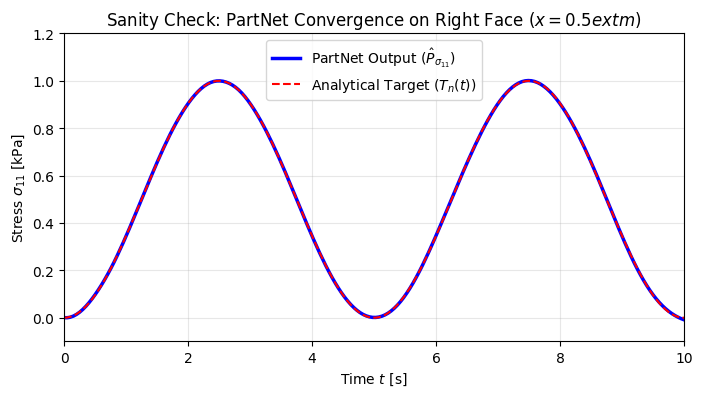

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import torch


device = next(part_model.parameters()).device


t_test = torch.linspace(0, 10.0, 200, dtype=torch.float64, device=device).unsqueeze(1)
x_test = torch.full_like(t_test, 0.5)
y_test = torch.full_like(t_test, 0.25)


with torch.no_grad():
    # part_model outputs P_u, P_v, P_s11, P_s22, P_s12
    P_u, P_v, P_s11, P_s22, P_s12 = part_model(x_test, y_test, t_test)


t_ana = np.linspace(0, 10.0, 200)
Tn = 0.5 * np.sin((2 * np.pi / 5.0) * t_ana + 1.5 * np.pi) + 0.5


plt.figure(figsize=(8, 4))
plt.plot(t_test.cpu().numpy(), P_s11.cpu().numpy(), 'b-', lw=2.5, label='PartNet Output ($\hat{P}_{\sigma_{11}}$)')
plt.plot(t_ana, Tn, 'r--', lw=1.5, label='Analytical Target ($T_n(t)$)')
plt.title('Sanity Check: PartNet Convergence on Right Face ($x=0.5\text{m}$)')
plt.xlabel('Time $t$ [s]')
plt.ylabel('Stress $\sigma_{11}$ [kPa]')
plt.xlim(0, 10.0)
plt.ylim(-0.1, 1.2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Resume training - from saved main net weights


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[System] Hardware acquired: {device}")


dist_dnet = DistNet([3, 20, 20, 20, 20, 5]).to(torch.float64).to(device)
part_dnet = PartNet([3, 20, 20, 20, 20, 5]).to(torch.float64).to(device)
pinn_model = PINN_Elastodynamics(dist_dnet, part_dnet, [3] + 8 * [70] + [5]).to(torch.float64).to(device)

save_path = '/content/drive/MyDrive/PINN/pinn_physics_weights.pth'
if os.path.exists(save_path):
    print(f"[System] Restoring state from: {save_path}...")
    pinn_model.load_state_dict(torch.load(save_path, map_location=device))
    print("Master Brain State restored")
else:
    raise FileNotFoundError(f"Autosave not found at {save_path}.")


for param in pinn_model.dist_net.parameters():
    param.requires_grad = False
for param in pinn_model.part_net.parameters():
    param.requires_grad = False

pinn_model.train()

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float64, device=device, requires_grad=True)

x_c, y_c, t_c = to_tensor(XYT_c[:, 0:1]), to_tensor(XYT_c[:, 1:2]), to_tensor(XYT_c[:, 2:3])
x_h, y_h, t_h = to_tensor(HOLE[:, 0:1]),  to_tensor(HOLE[:, 1:2]),  to_tensor(HOLE[:, 2:3])

def compute_loss():
    f_u, f_v, f_s11, f_s22, f_s12 = pinn_model.net_f_sig(x_c, y_c, t_c)
    loss_f_uv = torch.mean(f_u**2) + torch.mean(f_v**2)
    loss_f_s  = torch.mean(f_s11**2) + torch.mean(f_s22**2) + torch.mean(f_s12**2)
    raw_pde   = loss_f_uv + loss_f_s

    tx, ty    = pinn_model.net_hole_traction(x_h, y_h, t_h)
    raw_hole  = torch.mean(tx**2) + torch.mean(ty**2)

    total_loss = (10.0 * raw_pde) + (2500.0 * raw_hole)
    return total_loss, raw_pde, raw_hole


optimizer_adam_shock = optim.Adam(pinn_model.uv_net.parameters(), lr=1e-4)

print("\n STAGE 1: Adam training (300 Epochs at lr=1e-4)...")
for epoch in range(1, 301):
    optimizer_adam_shock.zero_grad()
    loss, raw_pde, raw_hole = compute_loss()
    loss.backward()
    optimizer_adam_shock.step()

    if epoch % 100 == 0:
        print(f"Adam Shock Epoch {epoch:3d} | Total: {loss.item():.3f}  [PDE MSE: {raw_pde.item():.2e} | Hole MSE: {raw_hole.item():.2e}]")


optimizer_lbfgs_phase3 = optim.LBFGS(
    pinn_model.uv_net.parameters(),
    max_iter=50000,
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    history_size=10,
    line_search_fn="strong_wolfe"
)

start_step = 5300 # 5000 base + 300 Adam steps
print(f"\n STAGE 2: L-BFGS from step {start_step}...")
iteration = [start_step]

def closure():
    optimizer_lbfgs_phase3.zero_grad()
    loss, raw_pde, raw_hole = compute_loss()
    loss.backward()

    iteration[0] += 1
    if iteration[0] % 100 == 0:
        print(f"L-BFGS Iter {iteration[0]:5d} | Total: {loss.item():.3f}  [PDE MSE: {raw_pde.item():.2e} | Hole MSE: {raw_hole.item():.2e}]")

    if iteration[0] % 500 == 0:
        torch.save(pinn_model.state_dict(), save_path)

    return loss

optimizer_lbfgs_phase3.step(closure)

final_loss, f_pde, f_hole = compute_loss()
print(f"   ↳ Final Loss: {final_loss.item():.4f} [PDE: {f_pde.item():.2e} | Hole: {f_hole.item():.2e}]")

[System] Hardware acquired: cuda
[System] Restoring state from: /content/drive/MyDrive/PINN/pinn_physics_weights.pth...
Master Brain State restored

 STAGE 1: Adam training (300 Epochs at lr=1e-4)...
Adam Shock Epoch 100 | Total: 0.327  [PDE MSE: 2.96e-02 | Hole MSE: 1.24e-05]
Adam Shock Epoch 200 | Total: 0.326  [PDE MSE: 2.95e-02 | Hole MSE: 1.24e-05]
Adam Shock Epoch 300 | Total: 0.325  [PDE MSE: 2.94e-02 | Hole MSE: 1.24e-05]

 STAGE 2: L-BFGS from step 5300...
L-BFGS Iter  5400 | Total: 0.322  [PDE MSE: 2.90e-02 | Hole MSE: 1.26e-05]
L-BFGS Iter  5500 | Total: 0.316  [PDE MSE: 2.84e-02 | Hole MSE: 1.29e-05]
L-BFGS Iter  5600 | Total: 0.311  [PDE MSE: 2.78e-02 | Hole MSE: 1.34e-05]
L-BFGS Iter  5700 | Total: 0.305  [PDE MSE: 2.71e-02 | Hole MSE: 1.38e-05]
L-BFGS Iter  5800 | Total: 0.299  [PDE MSE: 2.65e-02 | Hole MSE: 1.36e-05]
L-BFGS Iter  5900 | Total: 0.292  [PDE MSE: 2.57e-02 | Hole MSE: 1.41e-05]
L-BFGS Iter  6000 | Total: 0.281  [PDE MSE: 2.50e-02 | Hole MSE: 1.28e-05]
L-BFG

## Clear memory

In [ ]:
# @title
import gc
import torch

# Delete all tensors created in the last cell
for var in ['x_c','y_c','t_c','x_h','y_h','t_h',
            'f_u','f_v','f_s11','f_s22','f_s12',
            'loss','loss_f_uv','loss_f_s','loss_hole',
            'optimizer_kick']:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()
print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Reserved : {torch.cuda.memory_reserved()/1e9:.2f} GB")

Allocated: 4.47 GB
Reserved : 4.88 GB


In [ ]:
# Save the trained physics model to Drive
save_path = '/content/drive/MyDrive/PINN/pinn_physics_weights.pth'
torch.save(pinn_model.state_dict(), save_path)
print("Physics PINN safely backed up to Drive!")

Physics PINN safely backed up to Drive!


# Interference and Visualization

## Load model


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dist_dnet = DistNet([3, 20, 20, 20, 20, 5]).to(torch.float64).to(device)
part_dnet = PartNet([3, 20, 20, 20, 20, 5]).to(torch.float64).to(device)
pinn_model = PINN_Elastodynamics(dist_dnet, part_dnet, [3] + 8 * [70] + [5]).to(torch.float64).to(device)

save_path = '/content/drive/MyDrive/PINN/pinn_physics_weights.pth'
if os.path.exists(save_path):
    print(f"[System] Restoring state from: {save_path}...")
    pinn_model.load_state_dict(torch.load(save_path, map_location=device))
    print("Master Brain State restored")
else:
    raise FileNotFoundError(f"Autosave not found at {save_path}.")


for param in pinn_model.dist_net.parameters():
    param.requires_grad = False
for param in pinn_model.part_net.parameters():
    param.requires_grad = False

[System] Restoring state from: /content/drive/MyDrive/PINN/pinn_physics_weights.pth...
Master Brain State restored


In [ ]:
# Diagnostic
device = next(pinn_model.parameters()).device

x_test = torch.tensor([[0.25], [0.5], [0.1]], dtype=torch.float64, device=device)
y_test = torch.tensor([[0.25], [0.25], [0.15]], dtype=torch.float64, device=device)

for t_val in [0.0, 2.5, 5.0]:
    t_test = torch.full_like(x_test, t_val)
    with torch.no_grad():
        u, v, s11, s22, s12 = pinn_model.net_uv(x_test, y_test, t_test)
    print(f"t={t_val}s | s11={s11.cpu().numpy().ravel()} | "
          f"s22={s22.cpu().numpy().ravel()} | "
          f"u={u.cpu().numpy().ravel()}")

t=0.0s | s11=[-8.46738359e-05  3.68616813e-04 -3.09722909e-04] | s22=[-7.78902516e-05  2.99659363e-06 -6.83424387e-05] | u=[-8.14206672e-05 -6.94986746e-05 -8.43772421e-05]
t=2.5s | s11=[1.14258321 0.9999211  1.38537131] | s22=[-0.11649308  0.09558017 -0.01718381] | u=[0.01480144 0.02738451 0.00751298]
t=5.0s | s11=[-0.00739535  0.00151741  0.00796636] | s22=[-0.00700386  0.00031086 -0.02210698] | u=[0.00050749 0.00059247 0.00061596]


In [ ]:
with torch.no_grad():
    xp = torch.tensor([[0.0]], dtype=torch.float64, device=device)
    yp = torch.tensor([[0.1]], dtype=torch.float64, device=device)
    _, _, s11, _, _ = pinn_model.net_uv(xp, yp,
                      torch.tensor([[2.5]], dtype=torch.float64, device=device))
    print(f"σ₁₁ at (0, 0.1), t=2.5s: {s11.item():.4f} kPa  (target: ~3.3)")

σ₁₁ at (0, 0.1), t=2.5s: 1.6950 kPa  (target: ~3.3)


In [ ]:
device = next(pinn_model.parameters()).device
x_c = torch.tensor(XYT_c[:,0:1], dtype=torch.float64, device=device, requires_grad=True)
y_c = torch.tensor(XYT_c[:,1:2], dtype=torch.float64, device=device, requires_grad=True)
t_c = torch.tensor(XYT_c[:,2:3], dtype=torch.float64, device=device, requires_grad=True)
x_h = torch.tensor(HOLE[:,0:1],  dtype=torch.float64, device=device, requires_grad=True)
y_h = torch.tensor(HOLE[:,1:2],  dtype=torch.float64, device=device, requires_grad=True)
t_h = torch.tensor(HOLE[:,2:3],  dtype=torch.float64, device=device, requires_grad=True)

f_u, f_v, f_s11, f_s22, f_s12 = pinn_model.net_f_sig(x_c, y_c, t_c)
loss_f_uv = (f_u**2 + f_v**2).mean()
loss_f_s  = (f_s11**2 + f_s22**2 + f_s12**2).mean()

with torch.no_grad():
    _, _, s11h, s22h, s12h = pinn_model.net_uv(x_h, y_h, t_h)
    nx, ny = -x_h/0.1, -y_h/0.1
    loss_hole = ((s11h*nx + s12h*ny)**2 + (s12h*nx + s22h*ny)**2).mean()

print(f"loss_f_uv  : {loss_f_uv.item():.6f}  ← needs to reach ~0.001")
print(f"loss_f_s   : {loss_f_s.item():.6f}  ← needs to reach ~0.001")
print(f"loss_hole  : {loss_hole.item():.6f}  ← already good if <0.001")
print(f"total (10x): {10*(loss_f_uv + loss_f_s + 5*loss_hole).item():.6f}")

loss_f_uv  : 0.005609  ← needs to reach ~0.001
loss_f_s   : 0.009101  ← needs to reach ~0.001
loss_hole  : 0.000004  ← already good if <0.001
total (10x): 0.147299


Weights saved.


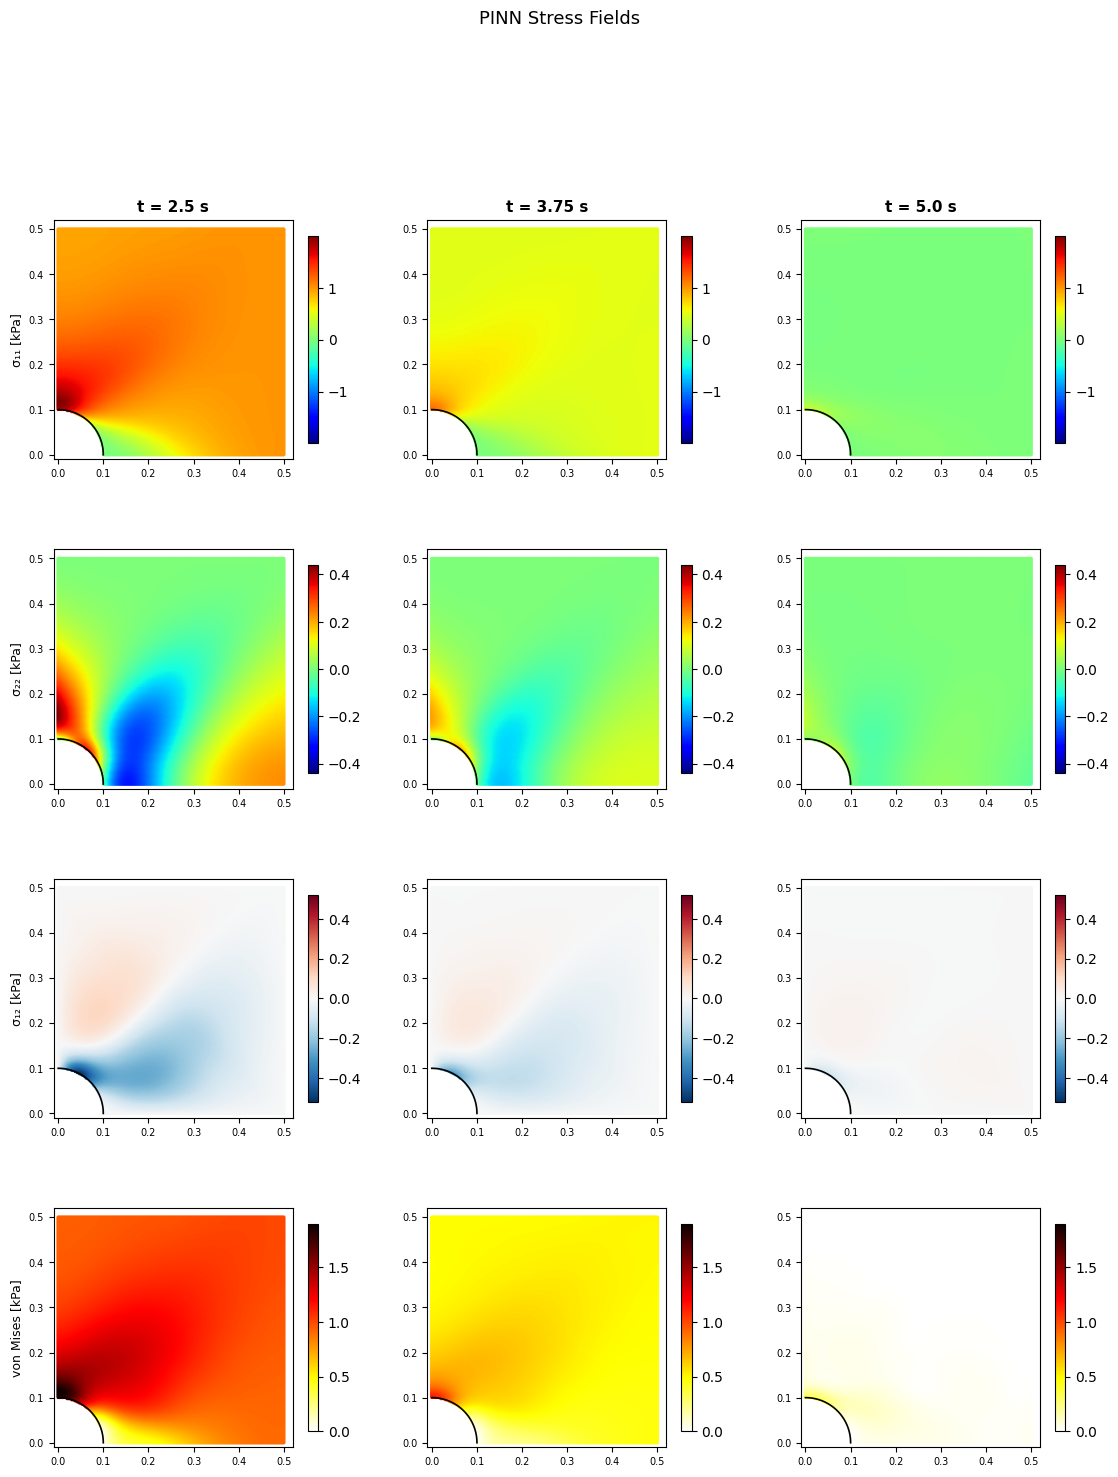

Saved → stress_snapshots.png


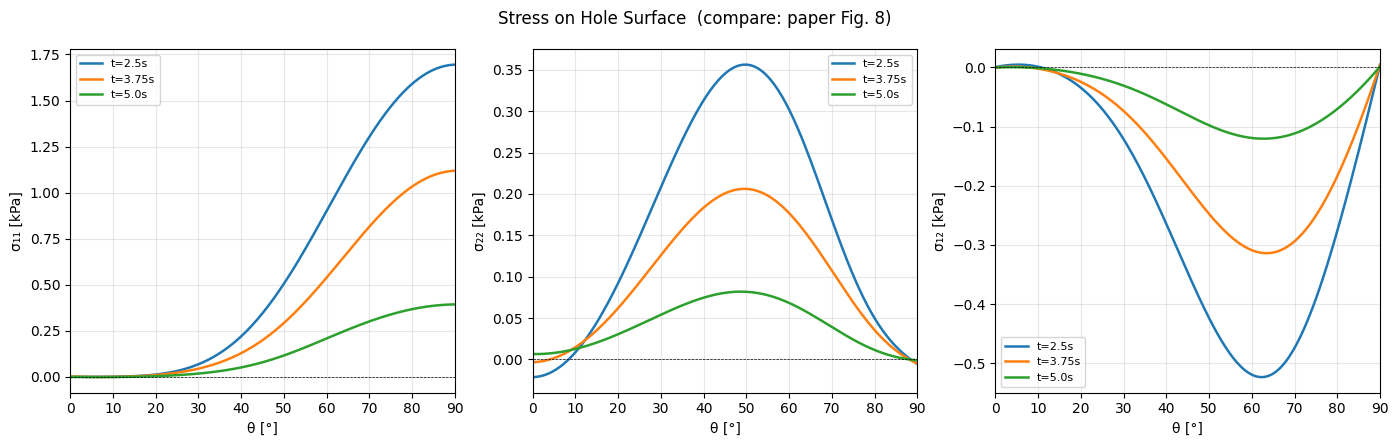

Saved → hole_surface_stress.png


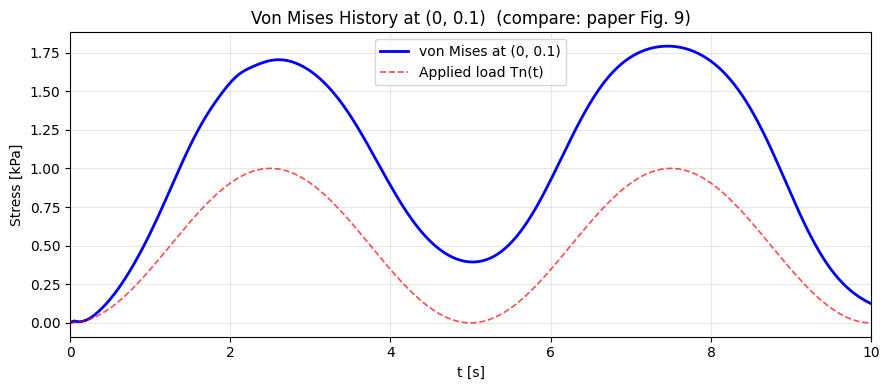

Saved → von_mises_history.png


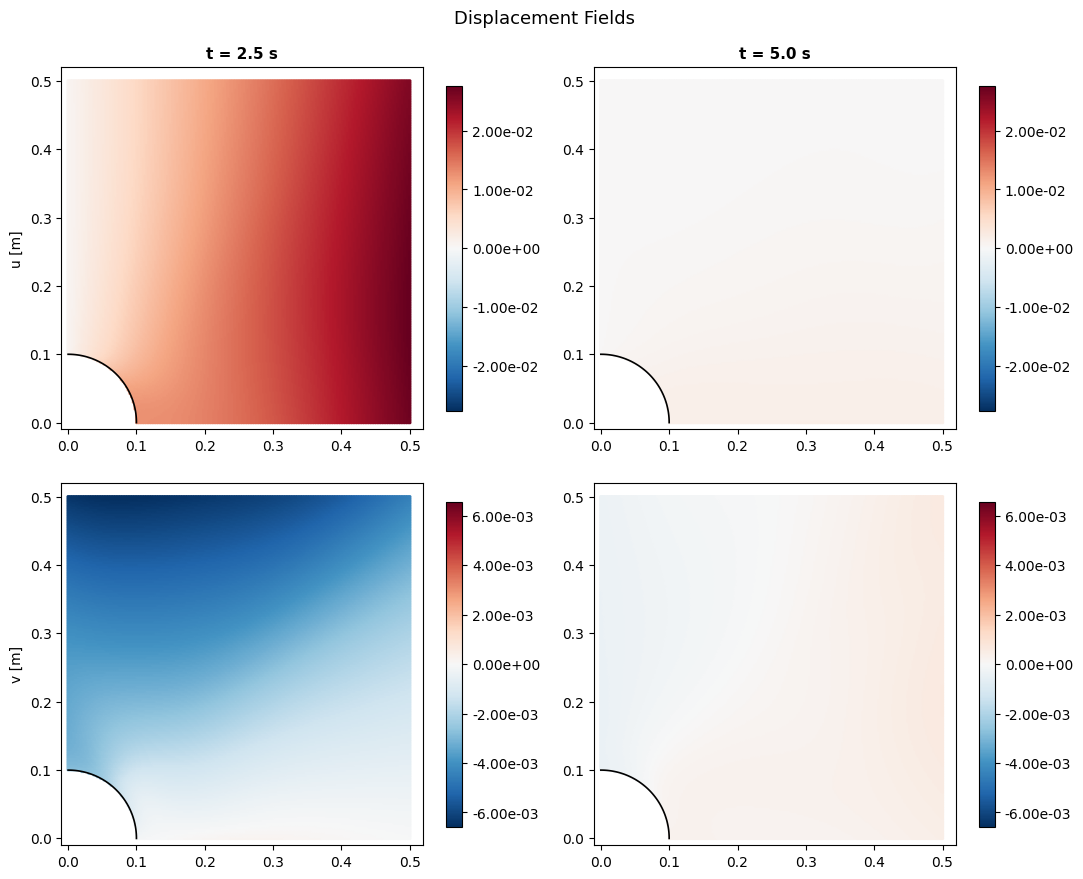

Saved → displacement_fields.png
Pass 1: calibrating color limits...
  σ₁₁ ±2.094 | von Mises max 2.002 kPa
Pass 2: building animation...
Saved → pinn_stress_animation.gif


In [ ]:
"""
Inference & Visualization
Requires pinn_model in memory. Run save block first, then plots.
"""
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, PillowWriter

SAVE_DIR = '/content/drive/MyDrive/PINN/'
HOLE_R   = 0.1
PI       = np.pi

torch.save(pinn_model.uv_net.state_dict(),   SAVE_DIR + 'uv_net_final.pth')
torch.save(pinn_model.dist_net.state_dict(), SAVE_DIR + 'dist_net_final.pth')
torch.save(pinn_model.part_net.state_dict(), SAVE_DIR + 'part_net_final.pth')
print("Weights saved.")


def infer_grid(model, t_val, n_grid=200):
    device   = next(model.parameters()).device
    x1d, y1d = np.linspace(0,0.5,n_grid), np.linspace(0,0.5,n_grid)
    xx, yy   = np.meshgrid(x1d, y1d)
    xf, yf   = xx.ravel()[:,None], yy.ravel()[:,None]
    mask     = np.sqrt(xf**2+yf**2).ravel() >= HOLE_R
    xv, yv   = xf[mask], yf[mask]
    xt = torch.tensor(xv, dtype=torch.float64, device=device)
    yt = torch.tensor(yv, dtype=torch.float64, device=device)
    with torch.no_grad():
        u, v, s11, s22, s12 = model.net_uv(xt, yt, torch.full_like(xt, t_val))
    s11n = s11.cpu().numpy().ravel()
    s22n = s22.cpu().numpy().ravel()
    s12n = s12.cpu().numpy().ravel()
    vm   = np.sqrt(s11n**2 - s11n*s22n + s22n**2 + 3*s12n**2)
    return (xv.ravel(), yv.ravel(),
            u.cpu().numpy().ravel(), v.cpu().numpy().ravel(),
            s11n, s22n, s12n, vm)

def arc():
    th = np.linspace(0, PI/2, 120)
    return HOLE_R*np.cos(th), HOLE_R*np.sin(th)

#  Plot 1: Stress field snapshots
def plot_field_snapshots(model, times=(2.5, 3.75, 5.0)):
    results = [infer_grid(model, t) for t in times]
    fields  = ['σ₁₁ [kPa]','σ₂₂ [kPa]','σ₁₂ [kPa]','von Mises [kPa]']
    cmaps   = ['jet','jet','RdBu_r','hot_r']
    idxs    = [4, 5, 6, 7]
    lims    = []
    for i, idx in enumerate(idxs):
        vals = np.concatenate([r[idx] for r in results])
        lims.append((0, vals.max()) if i == 3 else (-abs(vals).max(), abs(vals).max()))

    ax_x, ax_y = arc()
    fig = plt.figure(figsize=(4.5*len(times), 4*len(fields)))
    gs  = gridspec.GridSpec(len(fields), len(times), figure=fig, hspace=0.35, wspace=0.25)
    for col, (t, res) in enumerate(zip(times, results)):
        for row, (lbl, cmap, idx, (vlo,vhi)) in enumerate(zip(fields,cmaps,idxs,lims)):
            ax = fig.add_subplot(gs[row, col])
            sc = ax.scatter(res[0], res[1], c=res[idx], cmap=cmap, s=2,
                            vmin=vlo, vmax=vhi, rasterized=True)
            plt.colorbar(sc, ax=ax, shrink=0.85)
            ax.plot(ax_x, ax_y, 'k-', lw=1.2)
            ax.set_aspect('equal'); ax.set_xlim(-0.01,0.52); ax.set_ylim(-0.01,0.52)
            ax.tick_params(labelsize=7)
            if row == 0: ax.set_title(f't = {t} s', fontsize=11, fontweight='bold')
            if col == 0: ax.set_ylabel(lbl, fontsize=9)
    plt.suptitle("PINN Stress Fields", fontsize=13, y=1.01)
    plt.savefig(SAVE_DIR+'stress_snapshots.png', dpi=150, bbox_inches='tight')
    plt.show(); print("Saved → stress_snapshots.png")

# Plot 2: Hole surface stress vs angle (paper Fig. 8)
def plot_hole_surface_stress(model, times=(2.5, 3.75, 5.0)):
    device    = next(model.parameters()).device
    theta     = np.linspace(0, PI/2, 200)
    xh, yh    = HOLE_R*np.cos(theta), HOLE_R*np.sin(theta)
    colors    = ['tab:blue','tab:orange','tab:green']
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    for t, col in zip(times, colors):
        xt = torch.tensor(xh[:,None], dtype=torch.float64, device=device)
        yt = torch.tensor(yh[:,None], dtype=torch.float64, device=device)
        with torch.no_grad():
            _, _, s11, s22, s12 = model.net_uv(xt, yt, torch.full_like(xt, t))
        for ax, vals, lbl in zip(axes, [s11,s22,s12], ['σ₁₁ [kPa]','σ₂₂ [kPa]','σ₁₂ [kPa]']):
            ax.plot(np.degrees(theta), vals.cpu().numpy().ravel(),
                    color=col, lw=1.8, label=f't={t}s')
    for ax, lbl in zip(axes, ['σ₁₁ [kPa]','σ₂₂ [kPa]','σ₁₂ [kPa]']):
        ax.set_xlabel('θ [°]'); ax.set_ylabel(lbl); ax.set_xlim(0,90)
        ax.axhline(0,color='k',lw=0.5,ls='--'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.suptitle('Stress on Hole Surface  (compare: paper Fig. 8)', fontsize=12)
    plt.tight_layout()
    plt.savefig(SAVE_DIR+'hole_surface_stress.png', dpi=150, bbox_inches='tight')
    plt.show(); print("Saved → hole_surface_stress.png")

# Plot 3: Von Mises history at critical point (paper Fig. 9)
def plot_von_mises_history(model, n_time=200):
    device = next(model.parameters()).device
    t_vals = np.linspace(0, 10, n_time)
    xp = torch.tensor([[0.0]], dtype=torch.float64, device=device)
    yp = torch.tensor([[0.1]], dtype=torch.float64, device=device)
    vm_hist = []
    for tv in t_vals:
        with torch.no_grad():
            _, _, s11, s22, s12 = model.net_uv(xp, yp, torch.full_like(xp, tv))
        a, b, c = s11.item(), s22.item(), s12.item()
        vm_hist.append(np.sqrt(a**2 - a*b + b**2 + 3*c**2))
    Tn = 0.5*np.sin((2*PI/5)*t_vals + 1.5*PI) + 0.5
    fig, ax = plt.subplots(figsize=(9,4))
    ax.plot(t_vals, vm_hist, 'b-', lw=2, label='von Mises at (0, 0.1)')
    ax.plot(t_vals, Tn, 'r--', lw=1.2, alpha=0.7, label='Applied load Tn(t)')
    ax.set_xlabel('t [s]'); ax.set_ylabel('Stress [kPa]')
    ax.set_title('Von Mises History at (0, 0.1)  (compare: paper Fig. 9)')
    ax.set_xlim(0,10); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR+'von_mises_history.png', dpi=150, bbox_inches='tight')
    plt.show(); print("Saved → von_mises_history.png")

# Plot 4: Displacement fields
def plot_displacement_fields(model, times=(2.5, 5.0)):
    results    = [infer_grid(model, t) for t in times]
    u_lim      = abs(np.concatenate([r[2] for r in results])).max()
    v_lim      = abs(np.concatenate([r[3] for r in results])).max()
    ax_x, ax_y = arc()
    fig, axes  = plt.subplots(2, len(times), figsize=(5.5*len(times), 9))
    for col, (t, res) in enumerate(zip(times, results)):
        for row, (disp, lim, lbl) in enumerate([
            (res[2], u_lim, 'u [m]'), (res[3], v_lim, 'v [m]')
        ]):
            ax = axes[row, col]
            sc = ax.scatter(res[0], res[1], c=disp, cmap='RdBu_r', s=2,
                            vmin=-lim, vmax=lim, rasterized=True)
            plt.colorbar(sc, ax=ax, shrink=0.85, format='%.2e')
            ax.plot(ax_x, ax_y, 'k-', lw=1.2)
            ax.set_aspect('equal'); ax.set_xlim(-0.01,0.52); ax.set_ylim(-0.01,0.52)
            if row == 0: ax.set_title(f't = {t} s', fontsize=11, fontweight='bold')
            if col == 0: ax.set_ylabel(lbl, fontsize=10)
    plt.suptitle('Displacement Fields', fontsize=13)
    plt.tight_layout()
    plt.savefig(SAVE_DIR+'displacement_fields.png', dpi=150, bbox_inches='tight')
    plt.show(); print("Saved → displacement_fields.png")

#  Plot 5: Animated GIF
def generate_animation(model, t_start=0.5, t_end=10.0, num_frames=60,
                        n_grid=180, filename='pinn_stress_animation.gif'):
    device   = next(model.parameters()).device
    x1d, y1d = np.linspace(0,0.5,n_grid), np.linspace(0,0.5,n_grid)
    xx, yy   = np.meshgrid(x1d, y1d)
    xf, yf   = xx.ravel()[:,None], yy.ravel()[:,None]
    mask     = np.sqrt(xf**2+yf**2).ravel() >= HOLE_R
    xv, yv   = xf[mask], yf[mask]
    xt = torch.tensor(xv, dtype=torch.float64, device=device)
    yt = torch.tensor(yv, dtype=torch.float64, device=device)
    t_seq = np.linspace(t_start, t_end, num_frames)

    print("Pass 1: calibrating color limits...")
    all_s11, all_vm = [], []
    for tv in t_seq:
        with torch.no_grad():
            _, _, s11, s22, s12 = model.net_uv(xt, yt, torch.full_like(xt, tv))
        s11n = s11.cpu().numpy().ravel()
        s22n = s22.cpu().numpy().ravel()
        s12n = s12.cpu().numpy().ravel()
        all_s11.append(s11n)
        all_vm.append(np.sqrt(s11n**2 - s11n*s22n + s22n**2 + 3*s12n**2))
    s11_lim = abs(np.stack(all_s11)).max()
    vm_lim  = np.stack(all_vm).max()
    print(f"  σ₁₁ ±{s11_lim:.3f} | von Mises max {vm_lim:.3f} kPa")

    print("Pass 2: building animation...")
    ax_x, ax_y = arc()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax in (ax1, ax2):
        ax.set_aspect('equal'); ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
        ax.set_xlim(-0.01,0.52); ax.set_ylim(-0.01,0.52); ax.plot(ax_x,ax_y,'k-',lw=1.5)
    sc1 = ax1.scatter(xv,yv, c=all_s11[0], cmap='jet',   s=2, vmin=-s11_lim, vmax=s11_lim, rasterized=True)
    sc2 = ax2.scatter(xv,yv, c=all_vm[0],  cmap='hot_r', s=2, vmin=0,        vmax=vm_lim,  rasterized=True)
    fig.colorbar(sc1, ax=ax1, label='σ₁₁ [kPa]',      shrink=0.85)
    fig.colorbar(sc2, ax=ax2, label='von Mises [kPa]', shrink=0.85)
    ttl = fig.suptitle('', fontsize=12)

    def update(i):
        sc1.set_array(all_s11[i]); sc2.set_array(all_vm[i])
        ttl.set_text(f'PINN Elastodynamics  |  t = {t_seq[i]:.2f} s')
        return sc1, sc2, ttl

    ani = FuncAnimation(fig, update, frames=num_frames, interval=120, blit=True)
    ani.save(SAVE_DIR+filename, writer=PillowWriter(fps=10))
    plt.close(fig)
    print(f"Saved → {filename}")

plot_field_snapshots(pinn_model)
plot_hole_surface_stress(pinn_model)
plot_von_mises_history(pinn_model)
plot_displacement_fields(pinn_model)
generate_animation(pinn_model)

In [ ]:
# Check how many collocation points are near the hole
dist_from_hole = np.sqrt(XYT_c[:,0]**2 + XYT_c[:,1]**2)
near_hole = ((dist_from_hole >= 0.1) & (dist_from_hole <= 0.15)).sum()
total = len(XYT_c)
print(f"Points within 5mm annulus outside hole: {near_hole} / {total} = {near_hole/total:.1%}")

Points within 5mm annulus outside hole: 12824 / 56870 = 22.5%
